In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.integrate as integrate
from scipy import optimize

In [89]:
h = 1
m = 1
gamma = 0.5
x_interval = [-5, 15]
alpha = 1

In [108]:
# Параметры системы (пример для 2 уровней: V0=2.0, a=1.0)
V0 = 10.0      # Глубина потенциала
a = 1.0       # Характерная длина
m = 1.0       # Масса
hbar = 1.0    # Приведенная постоянная Планка
gamma = 0.5   # Фазовый сдвиг (для Морзе всегда 0.5)

In [109]:
def potential_energy(x):
    return V0 * (np.e**(-2*(x/a)) - 2*np.e**(-(x/a)))

In [110]:
def get_max_n():
    lam = np.sqrt(2 * m * V0) / (hbar * a)   # безразмерный параметр
    n_max = int(np.floor(lam - 0.5 + 1e-12))
    return max(n_max, -1)

In [111]:
get_max_n()

3

In [112]:
def get_ground_truth_energy(n):
    return - (hbar**2 / (2 * m)) * (np.sqrt(2 * m * V0) / hbar - a * (n + 0.5))**2

In [113]:
s = get_max_n()
max_n = 0
energies = []
while max_n < s:
    energies.append(get_ground_truth_energy(max_n))
    max_n+=1
max_n -= 1
print(max_n)
print(energies)

2
[-7.888932022500211, -4.4167960675006315, -1.9446601125010519]


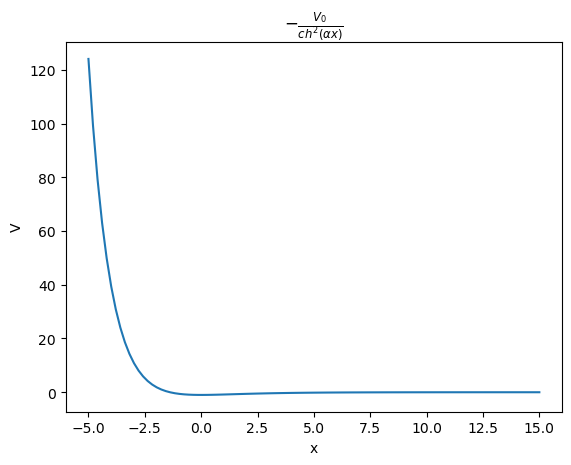

In [100]:
x_values = np.linspace(x_interval[0], x_interval[1], 100)
plt.title("$-\\frac{V_0}{ch^2(\\alpha x)}$")
plt.plot(x_values, [potential_energy(x) for x in x_values])
plt.xlabel('x')
plt.ylabel('V')
plt.show()

In [114]:
def momentum(energy, x, m=1.0):
    V = potential_energy(x)
    val = 2 * m * (energy - V)
    return np.sqrt(np.maximum(val, 0.0))

In [116]:
momentum(1.,1.)

3.7427893317852448

In [117]:
def bisect_root(f, x_low, x_high, tol=1e-10, max_iter=100):
    f_low = f(x_low)
    f_high = f(x_high)
    if f_low * f_high > 0:
        raise ValueError("No sign change in interval — root not bracketed.")
    for _ in range(max_iter):
        x_mid = 0.5 * (x_low + x_high)
        f_mid = f(x_mid)
        if abs(f_mid) < tol or (x_high - x_low) < tol:
            return x_mid
        if f_low * f_mid < 0:
            x_high = x_mid
            f_high = f_mid
        else:
            x_low = x_mid
            f_low = f_mid
    return 0.5 * (x_low + x_high)

In [122]:
def find_turning_points(energy, V0=1.0, a=1.0, x_min=-10.0, x_max=20.0):
    # V(x) -> +inf при x -> -inf, V(0) = -V0, V(x) -> 0 при x -> +inf
    # Ищем минимум (для разделения интервала) — у Морзе минимум в x=0
    x_min_point = 0.0

    # Левая точка: на [x_min, x_min_point]
    def f_left(x):
        return potential_energy(x) - energy

    # Правая точка: на [x_min_point, x_max]
    def f_right(x):
        return potential_energy(x) - energy

    # Убедимся, что значения на концах имеют разный знак
    # Левая: V(x_min) >> 0 > E, V(0) = -V0 < E (если E > -V0)
    x1 = bisect_root(f_left, x_min, x_min_point)

    # Правая: V(0) = -V0 < E, V(x_max) ≈ 0 > E (если E < 0)
    x2 = bisect_root(f_right, x_min_point, x_max)

    return x1, x2

In [123]:
def bohr_sommerfeld_quantization(energy, n):
    # Найти точки поворота
    try:
        x1, x2 = find_turning_points(energy)
    except ValueError as e:
        # Если не удаётся найти точки (например, E вне диапазона), возвращаем большое число
        return 1e6

    # Определим импульс как функцию x (для интегратора)
    def p_func(x):
        V = potential_energy(x)
        val = 2 * m * (energy - V)
        return np.sqrt(val) if val > 0 else 0.0

    # Интегрируем от x1 до x2
    integral, _ = integrate.quad(p_func, x1, x2, limit=100, epsabs=1e-8, epsrel=1e-8)

    # Возвращаем отклонение от условия квантования
    return integral - np.pi * hbar * (n + gamma)

In [124]:
from scipy.optimize import root_scalar

In [125]:
def find_energy_levels(n_max, e_int_base=(-V0 + 1e-8, -1e-8)):
    energy_levels = []
    E_base_low, E_base_high = e_int_base

    for n in range(0, n_max + 1):
        # Расширим интервал немного, чтобы поймать знак
        E_low = E_base_low
        E_high = E_base_high

        f_low = bohr_sommerfeld_quantization(E_low, n)
        f_high = bohr_sommerfeld_quantization(E_high, n)

        # Если оба значения NaN — пропускаем
        if not (np.isfinite(f_low) and np.isfinite(f_high)):
            raise RuntimeError(f"Non-finite values at bounds for n={n}")

        # Если знаки не разные — пробуем расширить интервал или уменьшить n_max
        if f_low * f_high > 0:
            # Попробуем немного расширить вглубь (особенно для больших n)
            # Но E не может быть <= -V0 или >= 0
            E_low_try = -V0 + 1e-12
            E_high_try = -1e-12
            f_low_try = bohr_sommerfeld_quantization(E_low_try, n)
            f_high_try = bohr_sommerfeld_quantization(E_high_try, n)
            if f_low_try * f_high_try > 0:
                # Уровень, вероятно, не существует в квазиклассике
                print(f"Warning: no sign change for n={n}. Skipping or reducing n_max.")
                # Можно остановиться, так как n идут по возрастанию
                break
            else:
                E_low, E_high = E_low_try, E_high_try
                f_low, f_high = f_low_try, f_high_try

        # Теперь вызываем root_scalar
        sol = optimize.root_scalar(
            lambda E: bohr_sommerfeld_quantization(E, n),
            bracket=[E_low, E_high],
            method='brentq'
        )

        if sol.converged:
            energy_levels.append(sol.root)
        else:
            raise RuntimeError(f"Root finding failed for n={n}")

    return energy_levels

In [126]:
def calculate_action(x1, x2, energy):
    def integrand(x):
        return momentum(energy, x)
    result, _ = integrate.quad(integrand, x1, x2)
    return result
calculate_action(-2, 2, potential_energy(2))

6.991806405992379

In [127]:
# def get_ground_truth_energy(n):
#     return - (a* (1 - (alpha/np.sqrt(2*m*a))*(n+0.5))**2)

In [128]:
eps = 1e-6
e_interval = [-V0 + eps, -eps]
e_values = np.linspace(e_interval[0], e_interval[1], 200)

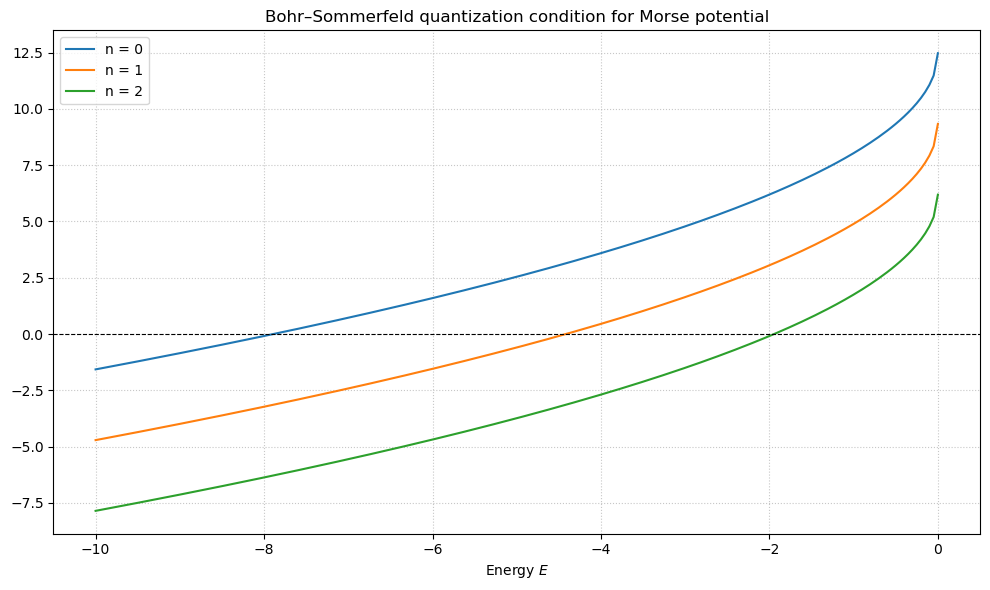

In [129]:
plt.figure(figsize=(10, 6))

for n in range(0, max_n + 1):
    y_values = []
    for e in e_values:
        val = bohr_sommerfeld_quantization(e, n)
        y_values.append(val.real if np.isfinite(val) else np.nan)
    plt.plot(e_values, y_values, label=f'n = {n}')

# Линия нуля
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.xlabel('Energy $E$')
# plt.ylabel(r'$\int_{x_1}^{x_2} p(x)\,dx - \pi\hbar(n + \gamma)$')
plt.title('Bohr–Sommerfeld quantization condition for Morse potential')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [130]:
energy_levels = find_energy_levels(max_n, e_interval)

In [131]:
energies_analytical = []
# Аналитические энергииenergies_analytical = []
n_max_analytical = int(get_max_n())
for n in range(n_max_analytical + 1):
    E_n = get_ground_truth_energy(n)
    energies_analytical.append(E_n)

In [132]:
energies_analytical

[-7.888932022500211,
 -4.4167960675006315,
 -1.9446601125010519,
 -0.47252415750147236]


Сравнение энергетических уровней:
n | E_analytical | E_numerical | Разница
------------------------------------------------


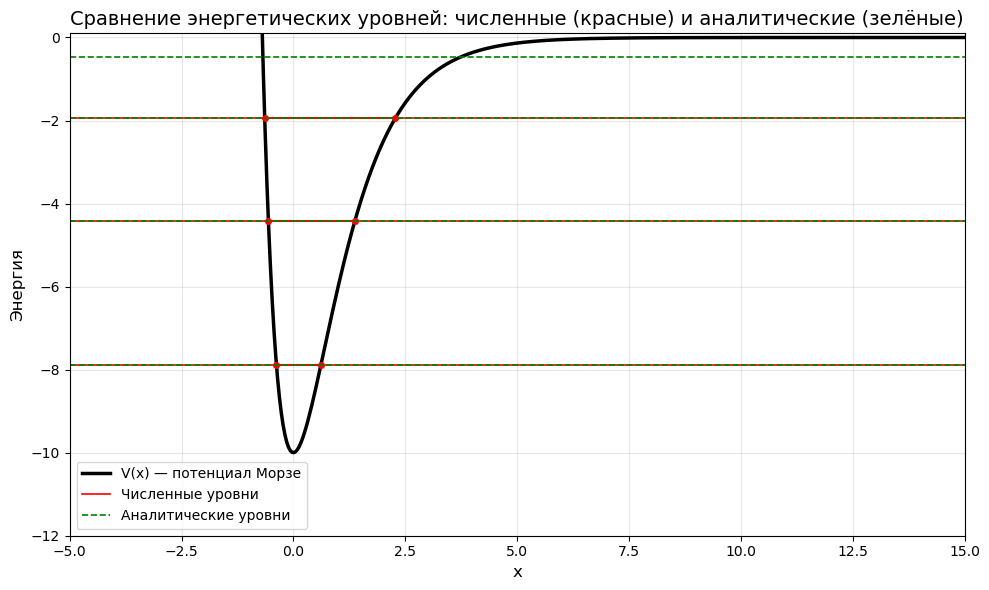

In [133]:
import matplotlib.pyplot as plt

# === 9. Сравнение аналитических и численных уровней ===
print("\nСравнение энергетических уровней:")
print("n | E_analytical | E_numerical | Разница")
print("-" * 48)

# Убедимся, что списки одинаковой длины (могут отличаться, если какой-то уровень не сошёлся)
# N = min(len(energies_analytical), len(energy_levels))
for n in range(N):
    E_analytical = energies_analytical[n]
    E_numerical = energy_levels[n]
    diff = abs(E_analytical - E_numerical)
    print(f"{n} | {E_analytical:12.6f} | {E_numerical:11.6f} | {diff:.2e}")

# === 10. Графическое представление уровней ===
x_values = np.linspace(x_interval[0], x_interval[1], 500)
plt.figure(figsize=(10, 6))
plt.plot(x_values, potential_energy(x_values), 'k-', linewidth=2.5, label='V(x) — потенциал Морзе')

# Численные уровни (красные)
for n, e in enumerate(energy_levels):
    plt.axhline(y=e, color='red', linestyle='-', linewidth=1.2,
                label='Численные уровни' if n == 0 else "_nolegend_")
    
    # Точки поворота
    try:
        x1, x2 = find_turning_points(e)
        plt.plot([x1, x2], [e, e], 'red', linewidth=1.5)
        plt.plot(x1, e, 'ro', markersize=4)
        plt.plot(x2, e, 'ro', markersize=4)
    except Exception as ex:
        print(f"Не удалось построить точки поворота для E={e:.4f}: {ex}")

# Аналитические уровни (зелёные, пунктир)
for n, e in enumerate(energies_analytical):
    plt.axhline(y=e, color='green', linestyle='--', linewidth=1.2,
                label='Аналитические уровни' if n == 0 else "_nolegend_")

plt.xlabel('x', fontsize=12)
plt.ylabel('Энергия', fontsize=12)
plt.title('Сравнение энергетических уровней: численные (красные) и аналитические (зелёные)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1.2 * V0, 0.1)  # Динамический предел по y с запасом
plt.xlim(x_interval)
plt.tight_layout()
plt.show()


Сравнение энергетических уровней:
n | E_analytical | E_numerical | Разница
---------------------------------------------
0 | -7.888932 | -7.888932 | 2.51e-13
1 | -4.416796 | -4.416796 | 1.17e-13
2 | -1.944660 | -1.944660 | 6.72e-13


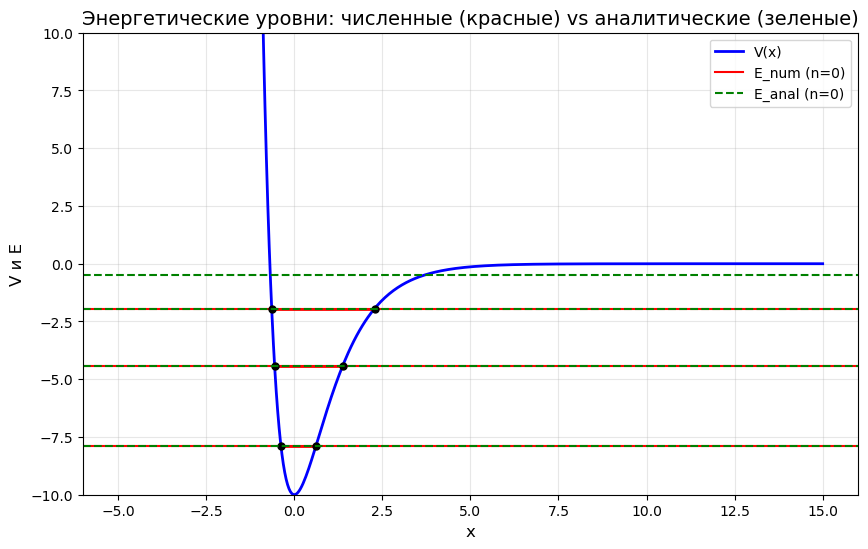

In [136]:
energy_levels = find_energy_levels(max_n, e_interval)

# === 9. Сравнение аналитических и численных уровней ===
print("\nСравнение энергетических уровней:")
print("n | E_analytical | E_numerical | Разница")
print("-" * 45)
for n in range(len(energy_levels)):
    E_analytical = energies_analytical[n]
    E_numerical = energy_levels[n]
    diff = abs(E_analytical - E_numerical)
    print(f"{n} | {E_analytical:0.6f} | {E_numerical:0.6f} | {diff:.2e}")

# === 10. Графическое представление уровней ===
x_values = np.linspace(x_interval[0], x_interval[1], 500)
plt.figure(figsize=(10, 6))
plt.plot(x_values, potential_energy(x_values), 'b-', linewidth=2, label='V(x)')

# Отмечаем уровни
for n, e in enumerate(energy_levels):
    plt.axhline(y=e, color='r', linestyle='-', 
                label=f'E_num (n={n})' if n == 0 else "_nolegend_")
    
    # Точки поворота
    x1, x2 = find_turning_points(e)
    plt.plot([x1, x2], [e, e], 'r-', linewidth=2)
    plt.plot(x1, e, 'ko', markersize=5)
    plt.plot(x2, e, 'ko', markersize=5)

# Аналитические уровни (для сравнения)
for n, e in enumerate(energies_analytical):
    plt.axhline(y=e, color='g', linestyle='--', 
                label=f'E_anal (n={n})' if n == 0 else "_nolegend_")

plt.xlabel('x', fontsize=12)
plt.ylabel('V и E', fontsize=12)
plt.title('Энергетические уровни: численные (красные) vs аналитические (зеленые)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-10, 10)
plt.show()

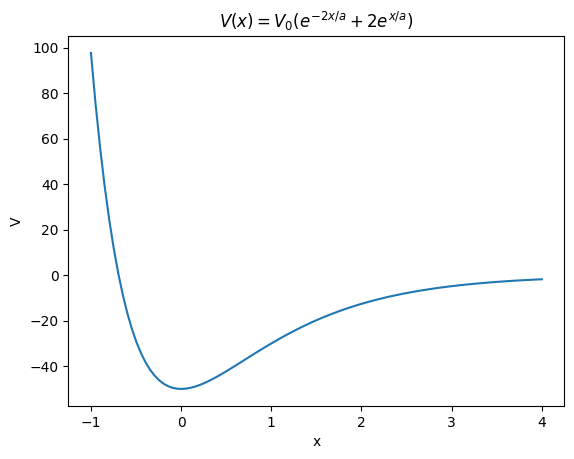

In [170]:
x_values = np.linspace(x_interval[0], x_interval[1], 100)
plt.title(r'$V(x)=V_0(e^{-2x/a}+2e^{x/a})$')
plt.plot(x_values, [potential_energy(x) for x in x_values])
plt.xlabel('x')
plt.ylabel('V')
plt.show()